In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator


Mounted at /content/drive


## Load Trained Model

In [2]:
# Custom focal loss (needed if you saved with custom_objects)
from tensorflow.keras import backend as K

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=1)
    return loss

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/pneumonia_project/vgg19_final_model_colab.h5",
    custom_objects={'loss': focal_loss()}
)


## Prepare Test Data

In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Curated X-Ray Dataset",
    target_size=(224, 224),
    batch_size=4,  # Predict one image at a time
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
print(class_names)


Found 9209 images belonging to 4 classes.
['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


## Predict on Test Images

In [6]:
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


2303/2303 ━━━━━━━━━━━━━━━━━━━━ 2903s 1s/step


## Calculate Accuracy

In [7]:
acc = accuracy_score(y_true, y_pred)
print(f"\n🔵 Test Accuracy: {acc*100:.2f}%")



🔵 Test Accuracy: 86.29%


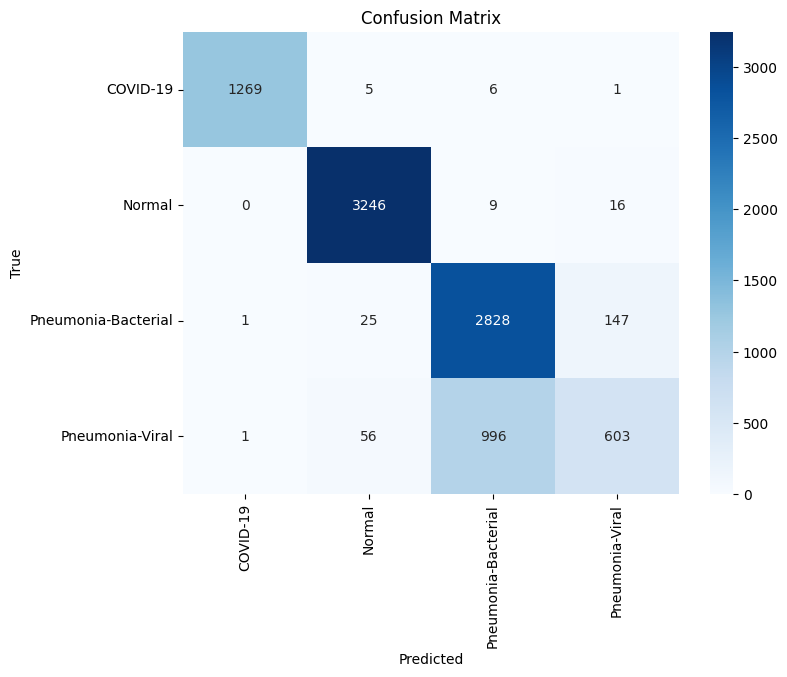

In [8]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [9]:
print("\n🧠 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



🧠 Classification Report:

                     precision    recall  f1-score   support

           COVID-19       1.00      0.99      0.99      1281
             Normal       0.97      0.99      0.98      3271
Pneumonia-Bacterial       0.74      0.94      0.83      3001
    Pneumonia-Viral       0.79      0.36      0.50      1656

           accuracy                           0.86      9209
          macro avg       0.87      0.82      0.83      9209
       weighted avg       0.87      0.86      0.85      9209



In [10]:
if len(class_names) > 2:
    y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=len(class_names))
    roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class="ovr")
    print(f"\n🔵 ROC AUC Score: {roc_auc:.3f}")



🔵 ROC AUC Score: 0.963
